In [1]:
from run_trial import objective


Loaded 9 MAF files
Processing tumor variants...


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 9/9 [00:31<00:00,  3.52s/it]


Done!
Loaded strelka variants for 9 patients
Parsing 2604 VCFs across 9 patients with 16 workers...


Cells: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2604/2604 [24:18<00:00,  1.78it/s]


Done parsing VCFs!
Parsed 2604 cells with 25840093 total variant records
Cell names cleaned
{'300105': 5056978, '300103': 5054695, '300101': 4968320, '300102': 4996963, '300104': 5036157, '300109': 5062295, '300110': 5941356, '300108': 5045256, '300106': 5008436}
Loaded AnnData: 1649 cells × 56600 genes
Identified 22 B cells
Loaded cell type metadata for 6003 cells
Classified 580 BM cells and 1684 PT cells


In [2]:
import optuna
from optuna.samplers import TPESampler
import seaborn as sns
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd

In [5]:
# Create study
study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))

print("Starting Bayesian optimization...")
print("This will run 100 trials. Each trial tests different hyperparameters.")
print()

# Run optimization
study.optimize(objective, n_trials=100, show_progress_bar=True)

print("\n" + "="*80)
print("OPTIMIZATION COMPLETE")
print("="*80)

[I 2026-03-03 12:58:34,026] A new study created in memory with name: no-name-8b4bd95f-7655-4d6d-a341-ce6d0ed15f63


Starting Bayesian optimization...
This will run 100 trials. Each trial tests different hyperparameters.



  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-03-03 12:58:47,904] Trial 0 finished with value: 0.7776572668112798 and parameters: {'min_dp': 4, 'min_alt_reads': 10, 'min_af': 0.6, 'max_blood_alt_counts': 6, 'min_tumor_alt_counts': 2, 'max_gnomAD_freq': 0.7000000000000001, 'max_dbSNP_freq': 0.2}. Best is trial 0 with value: 0.7776572668112798.
[I 2026-03-03 12:59:06,831] Trial 1 finished with value: 0.0 and parameters: {'min_dp': 9, 'min_alt_reads': 7, 'min_af': 0.55, 'max_blood_alt_counts': 0, 'min_tumor_alt_counts': 10, 'max_gnomAD_freq': 4.2, 'max_dbSNP_freq': 1.0}. Best is trial 0 with value: 0.7776572668112798.
[I 2026-03-03 12:59:24,246] Trial 2 finished with value: 0.8252980819077242 and parameters: {'min_dp': 2, 'min_alt_reads': 2, 'min_af': 0.30000000000000004, 'max_blood_alt_counts': 5, 'min_tumor_alt_counts': 5, 'max_gnomAD_freq': 1.4000000000000001, 'max_dbSNP_freq': 3.1}. Best is trial 2 with value: 0.8252980819077242.
[I 2026-03-03 12:59:40,072] Trial 3 finished with value: 0.7774769897130482 and parameters: {

In [6]:
# Best parameters
print("\nBest Parameters:")
print(f"  Cell-level:")
print(f"    min_dp:               {study.best_params['min_dp']}")
print(f"    min_alt_reads:        {study.best_params['min_alt_reads']}")
print(f"    min_af:               {study.best_params['min_af']:.4f}")
print(f"  Tumor-level:")
print(f"    max_blood_alt_counts: {study.best_params['max_blood_alt_counts']}")
print(f"    min_tumor_alt_counts: {study.best_params['min_tumor_alt_counts']}")
print(f"    max_gnomAD_freq:      {study.best_params['max_gnomAD_freq']:.4f}")
print(f"    max_dbSNP_freq:       {study.best_params['max_dbSNP_freq']:.4f}")

print("\nBest F1 Score:", f"{study.best_value:.4f}")

# Additional metrics for best trial
best_trial = study.best_trial
print("\nBest Trial Metrics:")
print(f"  Precision:       {best_trial.user_attrs['precision']:.4f}")
print(f"  Recall:          {best_trial.user_attrs['recall']:.4f}")
print(f"  True Positives:  {best_trial.user_attrs['true_pos']}")
print(f"  False Positives: {best_trial.user_attrs['false_pos']}")
print(f"  True Negatives:  {best_trial.user_attrs['true_neg']}")
print(f"  False Negatives: {best_trial.user_attrs['false_neg']}")

df_trials = study.trials_dataframe()


Best Parameters:
  Cell-level:
    min_dp:               1
    min_alt_reads:        2
    min_af:               0.1000
  Tumor-level:
    max_blood_alt_counts: 3
    min_tumor_alt_counts: 4
    max_gnomAD_freq:      1.3000
    max_dbSNP_freq:       4.2000

Best F1 Score: 0.8425

Best Trial Metrics:
  Precision:       0.9788
  Recall:          0.7396
  True Positives:  832
  False Positives: 18
  True Negatives:  18366
  False Negatives: 293


In [26]:
fig = optuna.visualization.plot_optimization_history(study)
fig.update_layout(width=1000, height=600)
fig.update_xaxes(title_text="Trial Number", range=[0, 100])
fig.update_yaxes(title_text="F1 Score", range=[0, 1])
fig.show()

In [8]:
# Plot parallel coordinate
fig = optuna.visualization.plot_parallel_coordinate(study)
fig.update_layout(width=1000, height=500)  # Adjust width and height as needed
fig.show()

In [9]:
# Plot slice
fig = optuna.visualization.plot_slice(study)
fig.show()

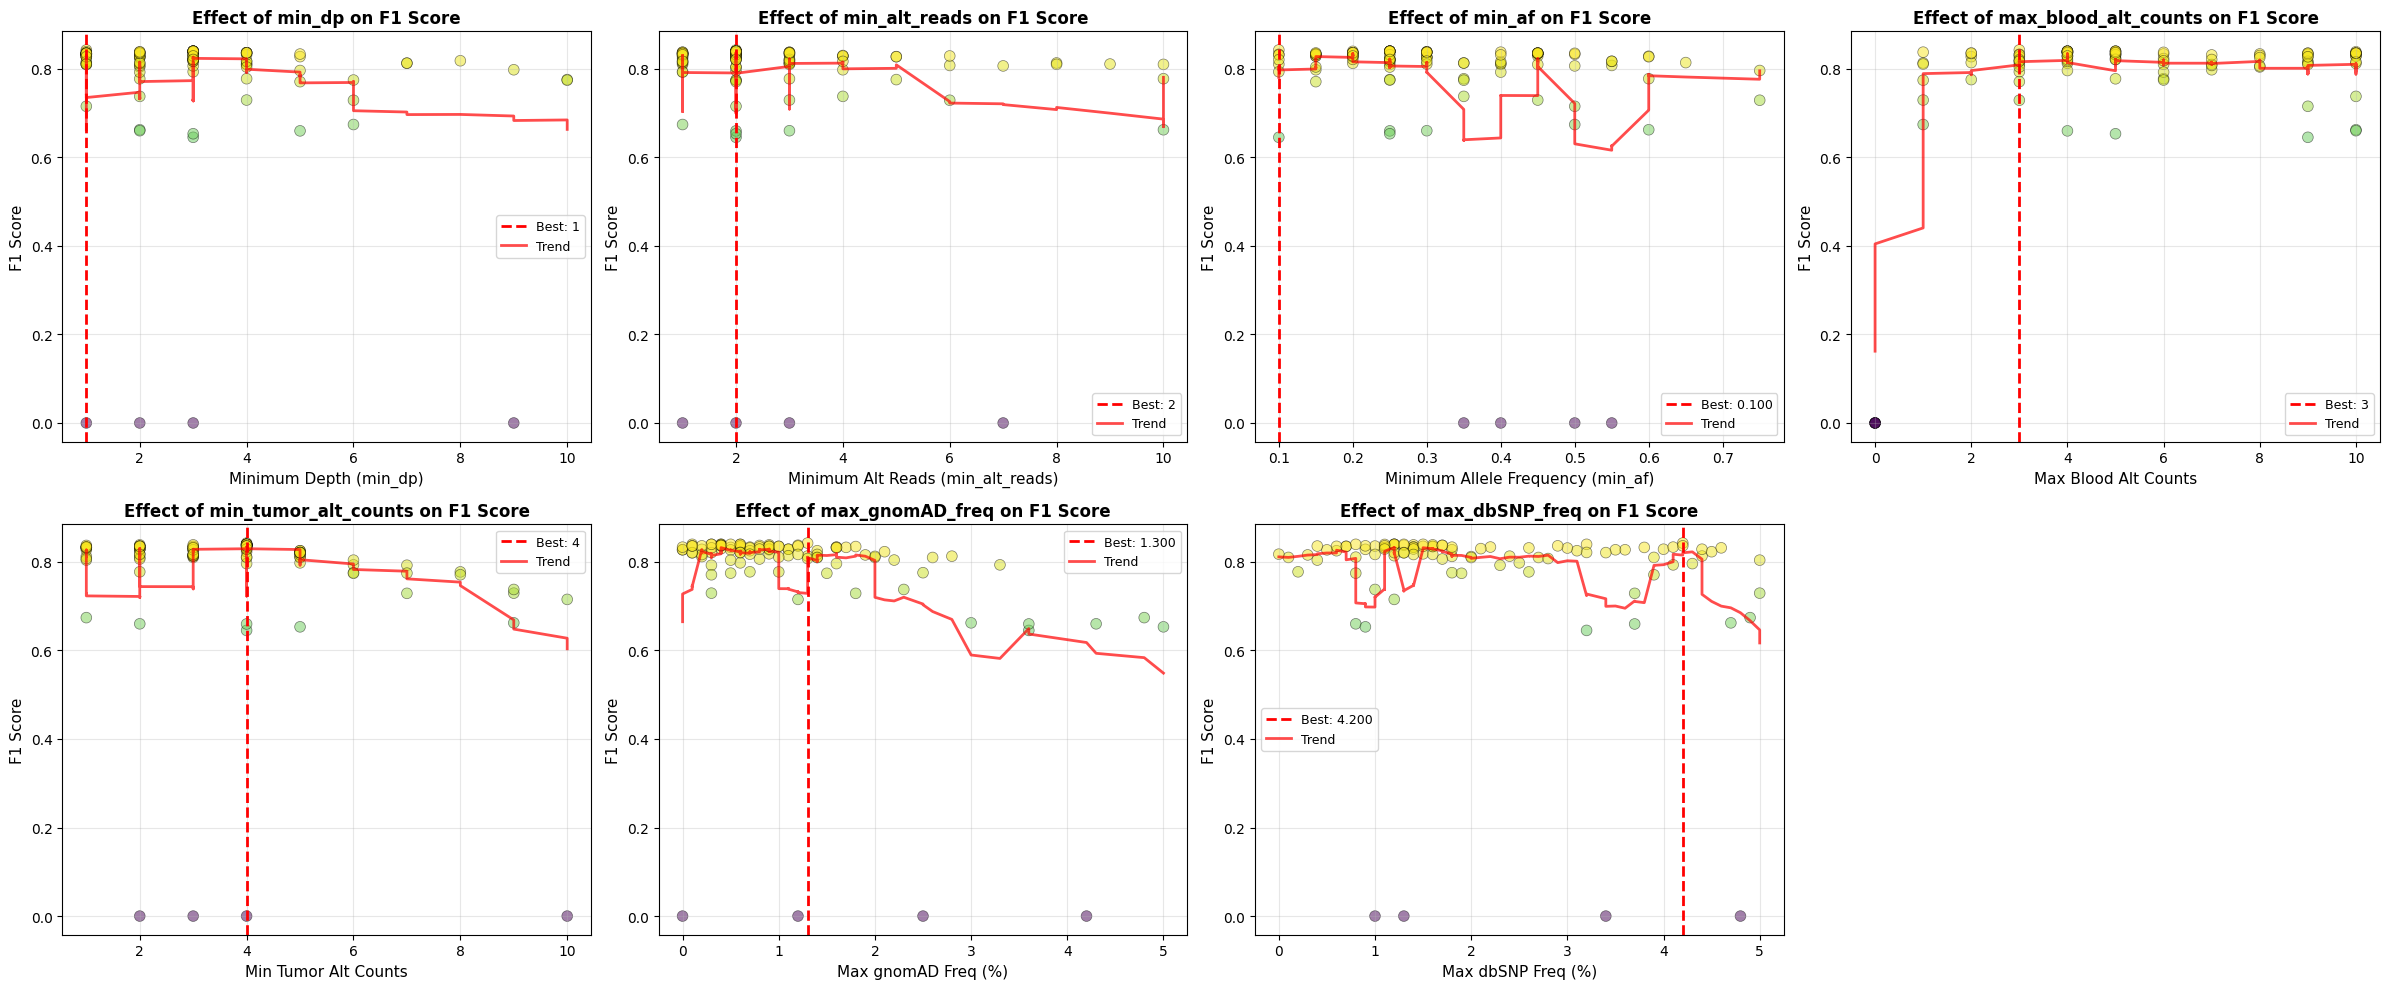

In [10]:
# Individual parameter slice plots
param_names = ['min_dp', 'min_alt_reads', 'min_af', 
               'max_blood_alt_counts', 'min_tumor_alt_counts', 'max_gnomAD_freq', 'max_dbSNP_freq']
param_labels = ['Minimum Depth (min_dp)', 'Minimum Alt Reads (min_alt_reads)', 'Minimum Allele Frequency (min_af)',
                'Max Blood Alt Counts', 'Min Tumor Alt Counts', 'Max gnomAD Freq (%)', 'Max dbSNP Freq (%)']
float_params = {'min_af', 'max_gnomAD_freq', 'max_dbSNP_freq'}

fig, axes = plt.subplots(2, 4, figsize=(24, 10))
axes = axes.flatten()

for idx, (param, label) in enumerate(zip(param_names, param_labels)):
    ax = axes[idx]
    
    param_vals = [trial.params[param] for trial in study.trials]
    f1_vals = [trial.value for trial in study.trials]
    
    scatter = ax.scatter(param_vals, f1_vals, alpha=0.5, s=60, c=f1_vals, 
                        cmap='viridis', edgecolors='black', linewidth=0.5)
    
    best_val = study.best_params[param]
    ax.axvline(best_val, color='red', linestyle='--', linewidth=2, 
               label=f'Best: {best_val:.3f}' if param in float_params else f'Best: {best_val}')
    
    df_temp = pd.DataFrame({'param': param_vals, 'f1': f1_vals}).sort_values('param')
    if len(df_temp) > 5:
        window_size = max(5, len(df_temp) // 10)
        df_temp['f1_smooth'] = df_temp['f1'].rolling(window=window_size, center=True, min_periods=1).mean()
        ax.plot(df_temp['param'], df_temp['f1_smooth'], 'r-', linewidth=2, alpha=0.7, label='Trend')
    
    ax.set_xlabel(label, fontsize=11)
    ax.set_ylabel('F1 Score', fontsize=11)
    ax.set_title(f'Effect of {param} on F1 Score', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

# Hide unused subplot
axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

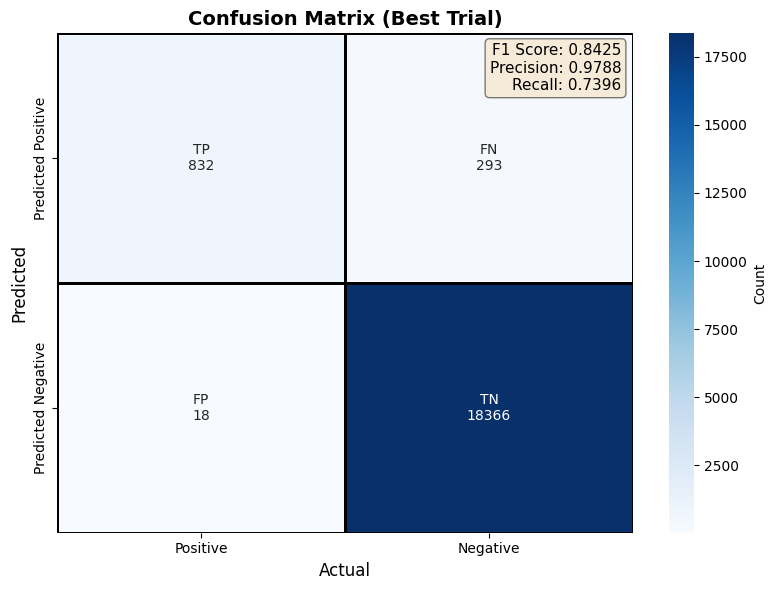

Confusion matrix saved to: confusion_matrix.png


In [ ]:
# 1. Confusion Matrix Heatmap for Best Trial
fig1, ax1 = plt.subplots(figsize=(8, 6))

best_trial = study.best_trial
tp = best_trial.user_attrs['true_pos']
fp = best_trial.user_attrs['false_pos']
tn = best_trial.user_attrs['true_neg']
fn = best_trial.user_attrs['false_neg']

confusion_matrix = np.array([[tp, fn], [fp, tn]])
labels = np.array([['TP\n'+str(tp), 'FN\n'+str(fn)], 
                   ['FP\n'+str(fp), 'TN\n'+str(tn)]])

sns.heatmap(confusion_matrix, annot=labels, fmt='', cmap='Blues', 
            cbar_kws={'label': 'Count'}, ax=ax1, linewidths=2, linecolor='black',
            xticklabels=['Predicted Positive', 'Predicted Negative'], 
            yticklabels=['Positive', 'Negative'])
ax1.set_title('Confusion Matrix (Best Trial)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Predicted', fontsize=12)
ax1.set_ylabel('Actual', fontsize=12)

# Add metrics text - moved to upper right inside the plot
metrics_text = f"F1 Score: {study.best_value:.4f}\n"
metrics_text += f"Precision: {best_trial.user_attrs['precision']:.4f}\n"
metrics_text += f"Recall: {best_trial.user_attrs['recall']:.4f}"
ax1.text(0.98, 0.98, metrics_text, transform=ax1.transAxes, 
        fontsize=11, verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print("Confusion matrix saved to: confusion_matrix.png")

In [12]:
# Show top 50 trials
all_param_cols = ['params_min_dp', 'params_min_alt_reads', 'params_min_af',
                  'params_max_blood_alt_counts', 'params_min_tumor_alt_counts', 
                  'params_max_gnomAD_freq', 'params_max_dbSNP_freq']
display_cols = ['number', 'value'] + all_param_cols + ['user_attrs_precision', 'user_attrs_recall']
display_names = ['Trial', 'F1 Score', 'min_dp', 'min_alt_reads', 'min_af',
                 'max_blood_alt', 'min_tumor_alt', 'max_gnomAD', 'max_dbSNP', 
                 'Precision', 'Recall']

df_top = df_trials.nlargest(50, 'value')[display_cols]
df_top.columns = display_names
print("\nTop 50 Trials:")
print(df_top.to_string(index=False))


Top 50 Trials:
 Trial  F1 Score  min_dp  min_alt_reads  min_af  max_blood_alt  min_tumor_alt  max_gnomAD  max_dbSNP  Precision   Recall
     8  0.842532       1              2    0.10              3              4         1.3        4.2   0.978824 0.739556
    70  0.839734       3              2    0.25              4              4         0.3        1.2   0.990338 0.728889
    71  0.839734       3              2    0.25              4              4         0.4        1.2   0.990338 0.728889
    72  0.839734       3              2    0.25              4              4         0.4        1.2   0.990338 0.728889
    74  0.839734       3              2    0.25              5              4         0.1        1.3   0.990338 0.728889
    85  0.839734       3              2    0.25              5              4         0.6        3.2   0.990338 0.728889
    91  0.839734       3              2    0.25              5              4         0.5        1.5   0.990338 0.728889
    92  0.839734

In [13]:
# Get the maximum F1 score
max_f1 = df_trials['value'].max()

# Filter to trials with max F1 score
best_trials = df_trials[df_trials['value'] == max_f1]

# Among ties, pick the trial with the lowest min_af
best_params = best_trials.loc[best_trials['params_min_af'].idxmin()]

# Display all parameters
all_param_cols = ['params_min_dp', 'params_min_alt_reads', 'params_min_af',
                  'params_max_blood_alt_counts', 'params_min_tumor_alt_counts',
                  'params_max_gnomAD_freq', 'params_max_dbSNP_freq']
display_cols = ['number', 'value'] + all_param_cols + ['user_attrs_precision', 'user_attrs_recall']
display_names = ['Trial', 'F1 Score', 'min_dp', 'min_alt_reads', 'min_af',
                 'max_blood_alt', 'min_tumor_alt', 'max_gnomAD', 'max_dbSNP',
                 'Precision', 'Recall']

df_best = best_params[display_cols].to_frame().T
df_best.columns = display_names
print("\nBest Trial:")
print(df_best.to_string(index=False))


Best Trial:
Trial  F1 Score min_dp min_alt_reads min_af max_blood_alt min_tumor_alt max_gnomAD max_dbSNP Precision    Recall
    8  0.842532      1             2    0.1             3             4        1.3       4.2  0.978824  0.739556


In [22]:
df_top.to_csv("./hyperparameter_tuning_results.csv")

In [23]:
from run_trial import apply_filters_to_all, apply_filters_tumors
from get_cell_variants import master_dict_all
from get_tumor_variants import patients, patient_to_tumor_variants
from get_epithelial_cells import pt_cells, ep_cells
from get_blood_variants import patient_to_blood_variants

In [24]:
def same_vs_diff_matches(master_dict, patient_to_tumor_variants, ep_cells, pt_cells, patients):
    """
    Calculate F1 score for a given set of filtered variants.
    master_dict_exonic: dict[patient][cell] -> set of (chrom, pos, ref, alt)
    """
    # Separate by tissue type
    master_dict_bm = {}
    master_dict_pt = {}
    
    for patient, cells_dict in master_dict.items():
        bm_dict = {}
        pt_dict = {}
        for cell_name, variants in cells_dict.items():
            if cell_name in pt_cells:
                pt_dict[cell_name] = variants
            else:
                bm_dict[cell_name] = variants
        master_dict_bm[patient] = bm_dict
        master_dict_pt[patient] = pt_dict
    
    # Calculate matches
    def match_mutations(x, y, master_dict_all):
        if x == y:
            target = patient_to_tumor_variants[y]
        else:
            target = patient_to_tumor_variants[y] - patient_to_tumor_variants[x]
        
        target = target - patient_to_blood_variants[x]

        num_matching_variants = []
        if x == y:
            cell_names = [e for e in list(master_dict_pt[x]) if e in ep_cells]
        else:
            cell_names = list(master_dict_all[x])
        
        for cell_name in cell_names:
            cell_set = master_dict_all[x][cell_name]
            if not cell_set:
                continue
            num_matching = len(cell_set & target)
            num_matching_variants.append(num_matching)
        
        return num_matching_variants
    
    same_pairs = [(p, p) for p in patients]
    diff_pairs = [(a, b) for a in patients for b in patients if a != b]
    
    num_same_matching = []
    num_diff_matching = []
    
    for x, y in same_pairs:
        num = match_mutations(x, y, master_dict)
        num_same_matching.extend(num)
    
    for x, y in diff_pairs:
        num = match_mutations(x, y, master_dict)
        num_diff_matching.extend(num)

    return num_same_matching, num_diff_matching

In [27]:
min_dp = 1
min_alt_reads = 2
min_af = 0.1
max_blood_alt_counts = 3
min_tumor_alt_counts = 4
max_gnomAD_freq = 1.3
max_dbSNP_freq = 4.2

master_dict_filtered = apply_filters_to_all(master_dict_all, min_dp, min_alt_reads, min_af)
patient_to_tumor_variants_filtered = apply_filters_tumors(patient_to_tumor_variants, max_blood_alt_counts, min_tumor_alt_counts, max_gnomAD_freq, max_dbSNP_freq)

same_matches, diff_matches = same_vs_diff_matches(master_dict_filtered, patient_to_tumor_variants_filtered, ep_cells, pt_cells, patients)

In [28]:
def plot_matching_violin(num_same_matching, num_diff_matching):
    """
    Create violin plot comparing same-patient vs nonspecific matching.
    
    Parameters:
    -----------
    num_same_matching : list
        List of matching variant counts for same-patient comparisons
    num_diff_matching : list
        List of matching variant counts for different-patient comparisons
    """
    fig, ax = plt.subplots()
    
    # Create violin plot
    parts = ax.violinplot(
        [num_same_matching, num_diff_matching],
        positions=[0, 1],
        showmeans=False,
        showmedians=False,
        showextrema=False,
        widths=0.7
    )
    
    # Style the violin plots
    for pc in parts['bodies']:
        pc.set_facecolor('#4A7BA7')
        pc.set_alpha(1.0)
        pc.set_edgecolor('black')
        pc.set_linewidth(0.5)
    
    # Add strip plot overlay for individual points
    np.random.seed(42)
    for i, data_points in enumerate([num_same_matching, num_diff_matching]):
        # Add jitter to x-coordinates
        x = np.random.normal(i, 0.04, size=len(data_points))
        ax.scatter(x, data_points, alpha=0.7, s=15, color='black', edgecolors='none')
    
    # Formatting
    ax.set_xticks([0, 1])
    ax.set_ylim(0)
    ax.set_xticklabels(['Same patient', 'Differing patients (non-specific matches)'])
    ax.set_ylabel('Number of matching mutations')
    ax.set_title('Mutation matching rates on optimized hyperparameter set')
    
    # Keep all spines visible for the box
    ax.spines['top'].set_visible(True)
    ax.spines['right'].set_visible(True)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(True)
    
    # Set spine colors and linewidth
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(0.8)
    
    plt.tight_layout()
    
    return fig

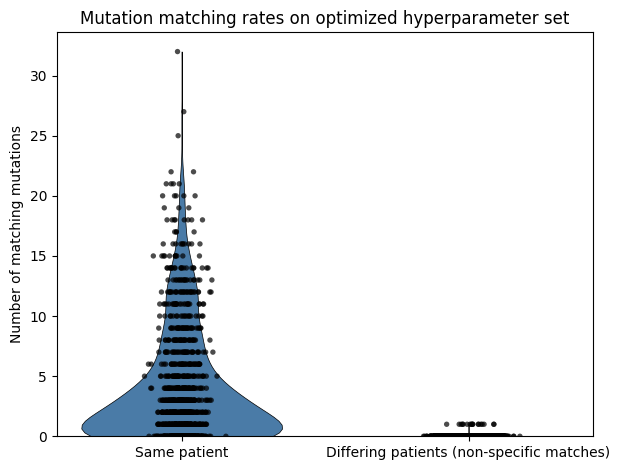

In [29]:
fig = plot_matching_violin(same_matches, diff_matches)
plt.show() 